# Strategy S5 — Multi-LVLM Response Fusion
## Thesis: Synthetic Data Augmentation for SHROOM-visions

**Core idea**: The dataset contains groups where the same (image, prompt) was given to  
2–16 different LVLMs. Within these groups, **different LVLMs hallucinate differently**  
— invention in one response, miscounting in another. Fusing their hallucination spans  
into a single dense training sample teaches the model to detect diverse co-occurring errors.

**From analysis notebook**:
- Multi-LVLM groups: 912 with 1 LVLM, 493 with 2, 184 with 3, up to 16 LVLMs per group (EN)
- 50.1% of multi-LVLM groups: ALL LVLMs hallucinate (consensus hard cases)
- Mean fraction of LVLMs that hallucinate within a group: 0.74
- These hard cases are ideal augmentation anchors

**Two fusion strategies** (both implemented, choose via `FUSION_MODE`):

**Mode A — Span Union** (no API needed, fast):  
Take the response with the most spans from a group as the base.  
Merge in spans from other LVLMs by fuzzy-finding their span text in the base response.  
Result: denser annotation on a real response.

**Mode B — Claude Fusion** (Claude API, high quality):  
Use Claude to write a NEW response for the same (image, prompt) that deliberately  
incorporates hallucination types seen across the group, then annotate the new response.

**Expected gain**: Better multi-span and multi-category detection; novel thesis contribution.

In [ ]:
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install",
    "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git", "--quiet"], check=False)
subprocess.run([sys.executable, "-m", "pip", "install",
    "--no-deps", "trl", "peft", "accelerate", "bitsandbytes", "--quiet"], check=False)
subprocess.run([sys.executable, "-m", "pip", "install",
    "qwen-vl-utils", "transformers>=4.45.0", "anthropic",
    "scipy", "scikit-learn", "matplotlib", "seaborn", "--quiet"], check=False)
print('Installation complete.')

Installation complete.


In [ ]:
import json, re, os, io, difflib, random, warnings, math, base64, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter, defaultdict
from typing import Optional
from scipy.stats import spearmanr
from tqdm.auto import tqdm
import torch
from datasets import Dataset
from PIL import Image
from qwen_vl_utils import process_vision_info
from sklearn.model_selection import train_test_split
import anthropic
warnings.filterwarnings('ignore')
print(f'CUDA: {torch.cuda.is_available()}')

CUDA: True


In [ ]:
MODEL_ID        = 'unsloth/Qwen2-VL-2B-Instruct'
LORA_R          = 16; LORA_ALPHA = 16; LORA_DROPOUT = 0.0
NUM_EPOCHS      = 2;  LR = 2e-4;  BATCH_SIZE = 1;  GRAD_ACCUM = 8
WARMUP_STEPS    = 50; MAX_SEQ_LEN = 2048; MAX_NEW_TOKENS = 512
SAVE_STEPS      = 200; LOG_STEPS = 10
TRAIN_LANGS     = ['en', 'fr', 'it', 'zh']
VAL_FRACTION    = 0.10; RANDOM_SEED = 42; MAX_VAL_SAMPLES = 200

STRATEGY        = 'S5_MultiLVLMFusion'
FUSION_MODE     = 'span_union'   # 'span_union' (no API) or 'claude_fusion' (Claude API)
ANTHROPIC_API_KEY = 'sk-ant-...'
CLAUDE_MODEL      = 'claude-sonnet-4-6'
MIN_GROUP_SIZE    = 2
MIN_HALLU_IN_GROUP = 2
MAX_SYNTH_PER_LANG = 500
MAX_SPANS_PER_SAMPLE = 8    # total span cap per fused sample
RESERVED_NEW_SLOTS   = 3    # slots reserved for spans from other LVLMs (base trimmed to MAX-RESERVED)
FUZZY_THRESHOLD   = 0.60
RATE_LIMIT_SLEEP  = 0.5

from google.colab import drive; drive.mount('/content/drive')
DRIVE_BASE        = Path('/content/drive/MyDrive/shroom-visions')
DATA_DIR          = DRIVE_BASE / 'distrib'
IMAGE_DIR         = DRIVE_BASE / 'shroom-vis-images'
OUTPUT_DIR        = DRIVE_BASE / f'ft_predictions_{STRATEGY}'
CKPT_DIR          = DRIVE_BASE / f'ft_checkpoints_{STRATEGY}'
BASELINE_CSV      = DRIVE_BASE / 'ft_predictions' / 'baseline_results.csv'
SYNTH_CACHE       = DRIVE_BASE / f'synth_cache_{STRATEGY}.json'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True); CKPT_DIR.mkdir(parents=True, exist_ok=True)

LABEL_ORDER  = ['invention', 'mischaracterization', 'OCR', 'miscounting', 'other']
VALID_LABELS = set(LABEL_ORDER)
LANGUAGES    = ['en', 'fr', 'it', 'zh']
LANG_NAMES   = {'en': 'English', 'fr': 'French', 'it': 'Italian', 'zh': 'Chinese'}

random.seed(RANDOM_SEED); np.random.seed(RANDOM_SEED); torch.manual_seed(RANDOM_SEED)
print(f'Strategy      : {STRATEGY}')
print(f'Fusion mode   : {FUSION_MODE}')
print(f'Cache         : {SYNTH_CACHE}')

Mounted at /content/drive
Strategy      : S5_MultiLVLMFusion
Fusion mode   : span_union
Cache         : /content/drive/MyDrive/shroom-visions/synth_cache_S5_MultiLVLMFusion.json


In [ ]:
def load_jsonl(path):
    return [json.loads(l) for l in path.read_text(encoding='utf-8').splitlines() if l.strip()]

train_raw, test_raw = {}, {}
for lang in LANGUAGES:
    train_raw[lang] = load_jsonl(DATA_DIR / f'shroom-vision.train.{lang}.labeled.jsonl')
    test_raw[lang]  = load_jsonl(DATA_DIR / f'shroom-vision.test.{lang}.unlabeled.jsonl')
    print(f'{lang.upper()}: {len(train_raw[lang])} train | {len(test_raw[lang])} test')

EN: 3799 train | 1201 test
FR: 3767 train | 1233 test
IT: 3746 train | 1254 test
ZH: 3790 train | 1210 test


---
## Strategy S5 — Multi-LVLM Fusion

### Step 1: Build (image, prompt) groups and find fusable groups

In [ ]:
def build_ip_groups(samples):
    """Group samples by (image_name, prompt) — each group is multiple LVLM responses."""
    groups = defaultdict(list)
    for s in samples:
        groups[(s['image_name'], s['prompt'])].append(s)
    return dict(groups)

groups_by_lang = {lang: build_ip_groups(train_raw[lang]) for lang in LANGUAGES}

print('Multi-LVLM group statistics:')
for lang in LANGUAGES:
    groups = groups_by_lang[lang]
    multi_groups = {k: v for k, v in groups.items() if len(v) >= MIN_GROUP_SIZE}
    # Groups where multiple LVLMs hallucinate
    fusable = {k: v for k, v in multi_groups.items()
               if sum(1 for s in v if s.get('labels')) >= MIN_HALLU_IN_GROUP}
    print(f'  {lang.upper()}: {len(groups)} total groups  |  {len(multi_groups)} multi-LVLM  |  {len(fusable)} fusable')

# Show example group
example_groups = {k: v for k, v in groups_by_lang['en'].items() if len(v) >= 3 and sum(1 for s in v if s.get('labels')) >= 2}
if example_groups:
    ex_key, ex_group = next(iter(example_groups.items()))
    print(f'\nExample group: image={ex_key[0]}, {len(ex_group)} LVLMs')
    for s in ex_group[:3]:
        labels = s.get('labels', [])
        cats = list(set(lb['label'] for lb in labels))
        print(f'  Response ({len(labels)} spans, cats={cats}): {s["response"][:80]!r}')

Multi-LVLM group statistics:
  EN: 1818 total groups  |  906 multi-LVLM  |  632 fusable
  FR: 1962 total groups  |  931 multi-LVLM  |  656 fusable
  IT: 1850 total groups  |  945 multi-LVLM  |  668 fusable
  ZH: 2147 total groups  |  899 multi-LVLM  |  522 fusable

Example group: image=frog_Purple_frog_(nasikabatrachus_sahyadrensis)_Purps.jpg, 4 LVLMs
  Response (0 spans, cats=[]): 'Based on the image, this frog is **not green** in color. It is primarily a **dar'
  Response (4 spans, cats=['mischaracterization']): 'In the image provided, there is no green frog. Instead, we see a frog with a dar'
  Response (2 spans, cats=['mischaracterization']): 'No, this frog is not green. It has a dark brown or purplish-brown coloration ove'


In [ ]:
def resolve_image_path(image_name, image_dir):
    p = image_dir / image_name
    if p.exists(): return p
    for ext in ['.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG']:
        alt = p.with_suffix(ext)
        if alt.exists(): return alt
    return None

_STOPWORDS = {
    'this','that','with','from','have','been','they','their','there','into','also',
    'which','when','what','will','were','would','could','should','very','more',
    'some','such','than','then','them','these','those','both','each','pour',
    'dans','avec','les','des','une','est','qui','que','sur','pour','mais',
    'con','del','della','delle','degli','che','non','una','sono','come',
}

def extract_span_keywords(text, min_len=4):
    if re.search(r'[一-鿿]', text):
        return [text[i:i+2] for i in range(len(text)-1) if len(text[i:i+2].strip()) == 2]
    tokens = re.findall(r'\b[a-zA-ZÀ-ÿ]{%d,}\b' % min_len, text)
    return [t for t in tokens if t.lower() not in _STOPWORDS]

def fuzzy_find(text, query, threshold=FUZZY_THRESHOLD):
    if not text or not query: return None
    pos = text.find(query)
    if pos != -1: return pos, pos + len(query)
    pos = text.lower().find(query.lower())
    if pos != -1: return pos, pos + len(query)
    if len(query) >= 4:
        tl, ql = text.lower(), query.lower()
        qlen = len(query)
        step = max(1, qlen // 4)
        best_r, best_pos = 0.0, 0
        for i in range(0, max(1, len(text)-qlen+1), step):
            r = difflib.SequenceMatcher(None, tl[i:i+qlen], ql).ratio()
            if r > best_r: best_r, best_pos = r, i
        for i in range(max(0, best_pos-step), min(len(text)-qlen+1, best_pos+step+1)):
            r = difflib.SequenceMatcher(None, tl[i:i+qlen], ql).ratio()
            if r > best_r: best_r, best_pos = r, i
        if best_r >= threshold: return best_pos, best_pos + qlen
    return None

def fuzzy_find_with_keyword_fallback(base_response, span_text, threshold=FUZZY_THRESHOLD):
    pos = fuzzy_find(base_response, span_text, threshold)
    if pos is not None: return pos
    keywords = extract_span_keywords(span_text)
    for kw in sorted(keywords, key=len, reverse=True):
        pos = fuzzy_find(base_response, kw, threshold=0.85)
        if pos is not None: return pos
    return None


def span_union_fusion(group):
    """
    Mode A: Take the most-hallucinated response as base.
    Pre-trim base labels to RESERVED_NEW_SLOTS slots so the cap never blocks
    the inner loop from even attempting spans from other LVLMs.
    """
    hallu_members = [s for s in group if s.get('labels')]
    if len(hallu_members) < MIN_HALLU_IN_GROUP: return None

    base = max(hallu_members, key=lambda s: len(s.get('labels', [])))
    base_response = base['response']

    # Reserve RESERVED_NEW_SLOTS slots for spans from other LVLMs.
    # Trim the base labels so the cap never blocks the inner loop from the start.
    max_base = max(1, MAX_SPANS_PER_SAMPLE - RESERVED_NEW_SLOTS)
    merged_labels = list(base.get('labels', []))[:max_base]
    used_chars    = set(i for lb in merged_labels for i in range(lb['start'], lb['end']))
    added = 0

    for member in hallu_members:
        if member['id'] == base['id']: continue
        for lb in member.get('labels', []):
            if len(merged_labels) >= MAX_SPANS_PER_SAMPLE: break
            span_text = member['response'][lb['start']:lb['end']]
            if not span_text.strip(): continue

            pos = fuzzy_find_with_keyword_fallback(base_response, span_text)
            if pos is None: continue
            start, end = pos

            overlap = len(set(range(start, end)) & used_chars)
            if overlap > (end - start) * 0.5: continue

            merged_labels.append({'start': start, 'end': end,
                                   'prob': lb['prob'], 'label': lb['label']})
            used_chars.update(range(start, end))
            added += 1

    if added == 0: return None

    return {
        'id': f'synth_s5_union_{base["id"]}',
        'language': base.get('language', ''),
        'prompt': base['prompt'],
        'image_name': base['image_name'],
        'response': base_response,
        'labels': sorted(merged_labels, key=lambda x: x['start']),
    }

print('Span-union fusion ready (pre-trimmed base, keyword fallback).')

Span-union fusion ready (pre-trimmed base, keyword fallback).


In [ ]:
# Claude-based fusion (Mode B) — only runs if FUSION_MODE == 'claude_fusion'
if FUSION_MODE == 'claude_fusion':
    client = anthropic.Anthropic(api_key=ANTHROPIC_API_KEY)

    def encode_image(img_path):
        ext = img_path.suffix.lower().lstrip('.')
        mt  = {'jpg': 'image/jpeg', 'jpeg': 'image/jpeg', 'png': 'image/png'}.get(ext, 'image/jpeg')
        with open(img_path, 'rb') as f:
            return base64.standard_b64encode(f.read()).decode(), mt

    def claude_fusion(group, image_dir):
        """
        Mode B: Use Claude to write a fused response incorporating hallucination
        patterns from multiple LVLMs in the group.
        """
        hallu_members = [s for s in group if s.get('labels')]
        if len(hallu_members) < MIN_HALLU_IN_GROUP: return None

        base = hallu_members[0]
        img_path = resolve_image_path(base['image_name'], image_dir)
        if img_path is None: return None

        # Summarize the hallucination types seen across the group
        all_cats   = list(set(lb['label'] for s in hallu_members for lb in s.get('labels', [])))
        all_spans  = [(s['response'][lb['start']:lb['end']], lb['label'])
                      for s in hallu_members for lb in s.get('labels', [])]
        examples   = '; '.join(f'{t} ({l})' for t, l in all_spans[:4])

        try:
            img_b64, mt = encode_image(img_path)
        except Exception: return None

        prompt = f"""Write a new VLM response to the question about the image that includes
hallucinations of these types: {all_cats}.

Hallucination examples from other LVLMs on this same image: {examples}

Question: {base['prompt']}

Rules:
1. Write a natural, fluent response (2-5 sentences)
2. Include 2-4 hallucinations, each a different type from the list above
3. Each hallucination must be factually wrong based on the image
4. The 'text' in each span must be the EXACT substring in response
5. Return ONLY valid JSON, no markdown

Return: {{"response": "...", "spans": [{{"text": "...", "label": "...", "prob": 1.0}}, ...]}}"""

        try:
            resp = client.messages.create(
                model=CLAUDE_MODEL, max_tokens=1024,
                messages=[{'role': 'user', 'content': [
                    {'type': 'image', 'source': {'type': 'base64', 'media_type': mt, 'data': img_b64}},
                    {'type': 'text', 'text': prompt},
                ]}]
            )
            raw = resp.content[0].text.strip()
            m = re.search(r'\{.*\}', raw, re.DOTALL)
            if not m: return None
            data = json.loads(m.group())
            fused_response = data.get('response', '')
            raw_spans = data.get('spans', [])
            if not fused_response or not raw_spans: return None

            labels = []
            for sp in raw_spans:
                text  = str(sp.get('text', '')).strip()
                label = str(sp.get('label', 'other')).lower()
                if label not in VALID_LABELS: label = 'other'
                if not text: continue
                pos = fused_response.find(text)
                if pos == -1: pos = fused_response.lower().find(text.lower())
                if pos == -1: continue
                labels.append({'start': pos, 'end': pos+len(text), 'prob': 1.0, 'label': label})

            if not labels: return None
            return {
                'id': f'synth_s5_claude_{base["id"]}',
                'language': base.get('language', ''),
                'prompt': base['prompt'],
                'image_name': base['image_name'],
                'response': fused_response,
                'labels': sorted(labels, key=lambda x: x['start']),
            }
        except Exception: return None

    print('Claude fusion function ready.')
else:
    print(f'Mode: {FUSION_MODE} — no Claude API needed.')

Mode: span_union — no Claude API needed.


In [ ]:
REGEN_ALL = False   # clear cache — v2 had cap bug that blocked dense-base groups

if SYNTH_CACHE.exists():
    synth_cache = json.loads(SYNTH_CACHE.read_text(encoding='utf-8'))
    print(f'Loaded cache: {sum(len(v) for v in synth_cache.values())} synthetic samples')
else:
    synth_cache = {lang: [] for lang in LANGUAGES}

if REGEN_ALL:
    for lang in LANGUAGES:
        dropped = len(synth_cache.get(lang, []))
        synth_cache[lang] = []
        if dropped:
            print(f'  Cleared {dropped} stale {lang.upper()} entries')

def save_cache():
    SYNTH_CACHE.parent.mkdir(parents=True, exist_ok=True)
    SYNTH_CACHE.write_text(json.dumps(synth_cache, ensure_ascii=False, indent=2), encoding='utf-8')

for lang in TRAIN_LANGS:
    groups = groups_by_lang[lang]
    fusable_groups = [group for group in groups.values()
                      if len(group) >= MIN_GROUP_SIZE
                      and sum(1 for s in group if s.get('labels')) >= MIN_HALLU_IN_GROUP]
    random.shuffle(fusable_groups)
    todo = fusable_groups[:MAX_SYNTH_PER_LANG]

    existing_ids = {s['id'] for s in synth_cache.get(lang, [])}
    print(f'\n[{lang.upper()}] {len(fusable_groups)} fusable groups → processing {len(todo)}')

    ok, fail = 0, 0
    for group in tqdm(todo, desc=lang.upper()):
        base_id = max(group, key=lambda s: len(s.get('labels', [])))['id']
        synth_id_prefix = 's5_union_' if FUSION_MODE == 'span_union' else 's5_claude_'
        if f'synth_{synth_id_prefix}{base_id}' in existing_ids:
            continue

        if FUSION_MODE == 'span_union':
            result = span_union_fusion(group)
        else:
            result = claude_fusion(group, IMAGE_DIR)
            time.sleep(RATE_LIMIT_SLEEP)

        if result:
            synth_cache.setdefault(lang, []).append(result)
            ok += 1
        else:
            fail += 1

        if (ok+fail) % 100 == 0:
            save_cache()

    save_cache()
    total = ok + fail
    print(f'  {lang.upper()}: {ok} fused, {fail} failed ({ok/max(total,1)*100:.1f}% success)')

synthetic_samples = {lang: synth_cache.get(lang, []) for lang in LANGUAGES}
print('\nSynthetic summary:')
for lang in LANGUAGES:
    n = len(synthetic_samples[lang])
    avg_spans = np.mean([len(s.get('labels',[])) for s in synthetic_samples[lang]]) if n else 0
    cnt = Counter(lb['label'] for s in synthetic_samples[lang] for lb in s.get('labels', []))
    print(f'  {lang.upper()}: {n} samples, avg {avg_spans:.1f} spans/sample  {dict(cnt)}')

Loaded cache: 1203 synthetic samples

[EN] 632 fusable groups → processing 500


EN:   0%|          | 0/500 [00:00<?, ?it/s]

  EN: 0 fused, 140 failed (0.0% success)

[FR] 656 fusable groups → processing 500


FR:   0%|          | 0/500 [00:00<?, ?it/s]

  FR: 0 fused, 214 failed (0.0% success)

[IT] 668 fusable groups → processing 500


IT:   0%|          | 0/500 [00:00<?, ?it/s]

  IT: 0 fused, 209 failed (0.0% success)

[ZH] 522 fusable groups → processing 500


ZH:   0%|          | 0/500 [00:00<?, ?it/s]

  ZH: 0 fused, 234 failed (0.0% success)

Synthetic summary:
  EN: 360 samples, avg 6.6 spans/sample  {'mischaracterization': 870, 'invention': 1246, 'OCR': 80, 'miscounting': 138, 'other': 39}
  FR: 286 samples, avg 6.3 spans/sample  {'mischaracterization': 562, 'invention': 1075, 'other': 35, 'miscounting': 92, 'OCR': 42}
  IT: 291 samples, avg 5.8 spans/sample  {'invention': 935, 'mischaracterization': 591, 'OCR': 30, 'miscounting': 72, 'other': 66}
  ZH: 266 samples, avg 5.9 spans/sample  {'mischaracterization': 618, 'miscounting': 186, 'invention': 633, 'other': 57, 'OCR': 65}


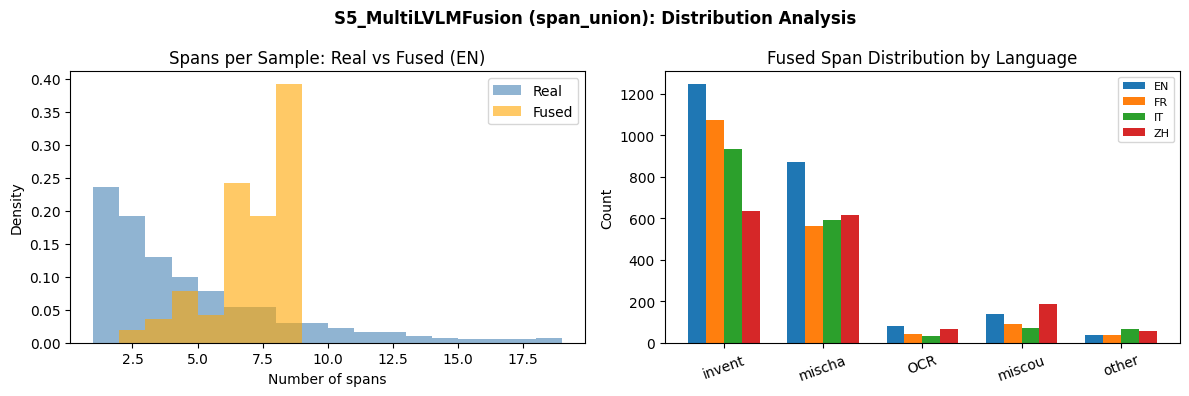

In [ ]:
# Compare span density: original vs fused
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
real_span_counts  = [len(s.get('labels',[])) for s in train_raw['en'] if s.get('labels')]
synth_span_counts = [len(s.get('labels',[])) for s in synthetic_samples['en'] if s.get('labels')]
ax.hist(real_span_counts,  bins=range(1,20), alpha=0.6, label='Real', color='steelblue', density=True)
ax.hist(synth_span_counts, bins=range(1,20), alpha=0.6, label='Fused', color='orange', density=True)
ax.set_title('Spans per Sample: Real vs Fused (EN)')
ax.set_xlabel('Number of spans'); ax.set_ylabel('Density'); ax.legend()

ax2 = axes[1]
all_cats = []
for lang in LANGUAGES:
    cnt = Counter(lb['label'] for s in synthetic_samples[lang] for lb in s.get('labels', []))
    all_cats.append([cnt.get(c,0) for c in LABEL_ORDER])
arr = np.array(all_cats)
x = np.arange(len(LABEL_ORDER))
for i, lang in enumerate(LANGUAGES):
    ax2.bar(x + i*0.18 - 0.27, arr[i], 0.18, label=lang.upper())
ax2.set_xticks(x); ax2.set_xticklabels([c[:6] for c in LABEL_ORDER], rotation=20)
ax2.set_title('Fused Span Distribution by Language')
ax2.set_ylabel('Count'); ax2.legend(fontsize=8)

plt.suptitle(f'{STRATEGY} ({FUSION_MODE}): Distribution Analysis', fontweight='bold')
plt.tight_layout(); plt.savefig(OUTPUT_DIR/'synth_distribution.png', dpi=150); plt.show()

In [ ]:
INSTRUCTION = """Identify all hallucinated text spans in the vision model's response.
A hallucination is text that is factually incorrect compared to what is actually visible in the image.

Categories:
- invention: entities or facts completely absent from the image
- mischaracterization: visible content described incorrectly
- OCR: text visible in the image is misread or mistranscribed
- miscounting: wrong quantity of visible items
- other: hallucination not fitting the above

Return ONLY a JSON array:
[{"text": "<exact text copied from the response>", "prob": <0.0-1.0>, "label": "<category>"}]
If there are no hallucinations, return: []"""

def build_conversation(sample, image_dir):
    img_path = resolve_image_path(sample['image_name'], image_dir)
    if img_path is None: return None
    response = sample['response']
    labels   = sample.get('labels', [])
    target_spans = []
    for lb in sorted(labels, key=lambda x: x['start']):
        span_text = response[lb['start']:lb['end']]
        if span_text.strip():
            target_spans.append({'text': span_text, 'prob': round(float(lb['prob']), 4), 'label': lb['label']})
    target_json = json.dumps(target_spans, ensure_ascii=False)
    user_text = f"{INSTRUCTION}\n\nQuestion asked: {sample['prompt']}\n\nVLM response to analyse:\n{response}"
    return {
        'messages': [
            {'role': 'user', 'content': [
                {'type': 'image', 'image': str(img_path)},
                {'type': 'text',  'text':  user_text},
            ]},
            {'role': 'assistant', 'content': [{'type': 'text', 'text': target_json}]},
        ],
        '_id': sample['id'], '_lang': sample.get('language',''),
        '_response': response, '_labels': labels,
    }

def build_inference_conversation(sample, image_dir):
    img_path = resolve_image_path(sample['image_name'], image_dir)
    if img_path is None: return None
    user_text = f"{INSTRUCTION}\n\nQuestion asked: {sample['prompt']}\n\nVLM response to analyse:\n{sample['response']}"
    return {
        'messages': [{'role': 'user', 'content': [
            {'type': 'image', 'image': str(img_path)},
            {'type': 'text',  'text':  user_text},
        ]}],
        '_id': sample['id'], '_lang': sample.get('language',''),
        '_response': sample['response'], '_labels': sample.get('labels', []),
    }

all_train_convs, all_val_convs = [], []
for lang in TRAIN_LANGS:
    samples = train_raw[lang]
    hallu = [s for s in samples if s.get('labels')]
    clean = [s for s in samples if not s.get('labels')]
    h_tr, h_val = train_test_split(hallu, test_size=VAL_FRACTION, random_state=RANDOM_SEED)
    c_tr, c_val = train_test_split(clean, test_size=VAL_FRACTION, random_state=RANDOM_SEED)
    lang_train = h_tr + c_tr + synthetic_samples[lang]
    lang_val   = h_val + c_val
    skipped = 0
    for s in lang_train:
        conv = build_conversation(s, IMAGE_DIR)
        if conv: all_train_convs.append(conv)
        else: skipped += 1
    for s in lang_val:
        conv = build_inference_conversation(s, IMAGE_DIR)
        if conv: all_val_convs.append(conv)
        else: skipped += 1
    print(f'{lang.upper()}: {len(lang_train)} train (real={len(h_tr)+len(c_tr)}, synth={len(synthetic_samples[lang])}) | {len(lang_val)} val | {skipped} skipped')

random.shuffle(all_train_convs)
print(f'Total train: {len(all_train_convs):,}  |  Total val: {len(all_val_convs):,}')

EN: 3778 train (real=3418, synth=360) | 381 val | 0 skipped
FR: 3675 train (real=3389, synth=286) | 378 val | 0 skipped
IT: 3662 train (real=3371, synth=291) | 375 val | 0 skipped
ZH: 3676 train (real=3410, synth=266) | 380 val | 0 skipped
Total train: 14,791  |  Total val: 1,514


---
## Model Loading & Training

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
Loading unsloth/Qwen2-VL-2B-Instruct...
==((====))==  Unsloth 2026.6.7: Fast Qwen2_Vl patching. Transformers: 5.5.0.
   \\   /|    NVIDIA A100-SXM4-40GB. Num GPUs = 1. Max memory: 39.494 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/2.46G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/238 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/572 [00:00<?, ?B/s]

...

Unsloth: Will smartly offload gradients to save VRAM!
Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.


Step,Training Loss
10,2.415344
20,2.021412
30,1.461754
40,0.772298
50,0.633531
60,0.577522
70,0.490503
80,0.506152
90,0.519736
100,0.574466


Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/shroom-visions/ft_checkpoints_S5_MultiLVLMFusion/checkpoint-200/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/shroom-visions/ft_checkpoints_S5_MultiLVLMFusion/checkpoint-400/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/shroom-visions/ft_checkpoints_S5_MultiLVLMFusion/checkpoint-600/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/shroom-visions/ft_checkpoints_S5_MultiLVLMFusion/checkpoint-800/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/shroom-visions/ft_checkpoints_S5_MultiLVLMFusion/checkpoint-1000/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/shroom-visions/ft_checkpoints_S5_MultiLVLMFusion/checkpoint-1200/tokenizer_config.json.
Unsloth: Restored added_tokens_d

Loss: 0.4283  Runtime: 443.6 min


Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/shroom-visions/ft_checkpoints_S5_MultiLVLMFusion/final_adapter/tokenizer_config.json.


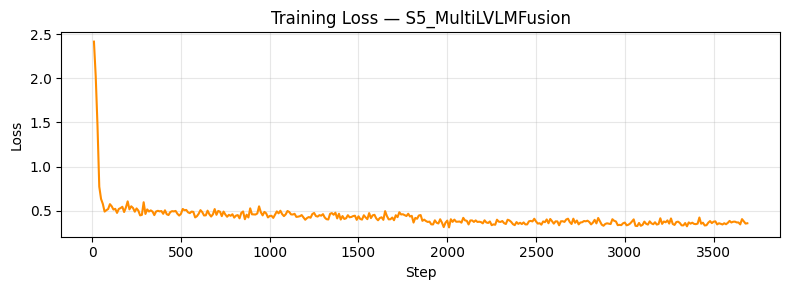

In [ ]:
from unsloth import FastVisionModel, is_bf16_supported
from trl import SFTTrainer, SFTConfig
from unsloth.trainer import UnslothVisionDataCollator

print(f'Loading {MODEL_ID}...')
model, processor = FastVisionModel.from_pretrained(
    MODEL_ID, load_in_4bit=True, use_gradient_checkpointing='unsloth')
model = FastVisionModel.get_peft_model(
    model, finetune_vision_layers=False, finetune_language_layers=True,
    finetune_attention_modules=True, finetune_mlp_modules=True,
    r=LORA_R, lora_alpha=LORA_ALPHA, lora_dropout=LORA_DROPOUT,
    bias='none', random_state=RANDOM_SEED,
)
hf_train = Dataset.from_list([{'messages': c['messages']} for c in all_train_convs])
print(f'HF dataset: {len(hf_train):,} samples')
trainer = SFTTrainer(
    model=model, tokenizer=processor.tokenizer,
    data_collator=UnslothVisionDataCollator(model, processor),
    train_dataset=hf_train,
    args=SFTConfig(
        output_dir=str(CKPT_DIR), num_train_epochs=NUM_EPOCHS,
        per_device_train_batch_size=BATCH_SIZE, gradient_accumulation_steps=GRAD_ACCUM,
        warmup_steps=WARMUP_STEPS, learning_rate=LR, lr_scheduler_type='cosine',
        fp16=not is_bf16_supported(), bf16=is_bf16_supported(),
        logging_steps=LOG_STEPS, save_steps=SAVE_STEPS, save_total_limit=2,
        optim='adamw_8bit', weight_decay=0.01, seed=RANDOM_SEED,
        report_to='none', remove_unused_columns=False,
        dataset_text_field='', dataset_kwargs={'skip_prepare_dataset': True},
        max_seq_length=MAX_SEQ_LEN,
    ),
)
print(f'Training {STRATEGY}...')
import glob as _glob; _ckpts = sorted(
    _glob.glob(str(CKPT_DIR / 'checkpoint-*')),
    key=lambda x: int(x.split("checkpoint-")[-1])
)
_resume = _ckpts[-1] if _ckpts else False
if _resume: print(f'Resuming from checkpoint: {_resume}')
train_result = trainer.train(resume_from_checkpoint=_resume)
print(f'Loss: {train_result.training_loss:.4f}  Runtime: {train_result.metrics.get("train_runtime",0)/60:.1f} min')
adapter_dir = CKPT_DIR / 'final_adapter'
model.save_pretrained(adapter_dir); processor.save_pretrained(adapter_dir)

logs = [e for e in trainer.state.log_history if 'loss' in e]
if logs:
    plt.figure(figsize=(8,3))
    plt.plot([e['step'] for e in logs], [e['loss'] for e in logs], color='darkorange')
    plt.title(f'Training Loss — {STRATEGY}'); plt.xlabel('Step'); plt.ylabel('Loss')
    plt.grid(True,alpha=0.3); plt.tight_layout()
    plt.savefig(OUTPUT_DIR/'training_loss.png',dpi=150); plt.show()

Evaluating EN (200 samples)...


EN:   0%|          | 0/200 [00:00<?, ?it/s]

Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_gene

Evaluating FR (200 samples)...


FR:   0%|          | 0/200 [00:00<?, ?it/s]

...

Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_gene

Evaluating ZH (200 samples)...


ZH:   0%|          | 0/200 [00:00<?, ?it/s]

Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_gene

RESULTS — S5_MultiLVLMFusion (mode=span_union)
[EN]  IoU=0.2323  Spearman=0.2854  CatF1=0.2274
[FR]  IoU=0.2975  Spearman=0.3084  CatF1=0.3107
[IT]  IoU=0.2978  Spearman=0.3346  CatF1=0.2591
[ZH]  IoU=0.3107  Spearman=0.3406  CatF1=0.2359
[OVERALL]  IoU=0.2846  Spearman=0.3172  CatF1=0.2493


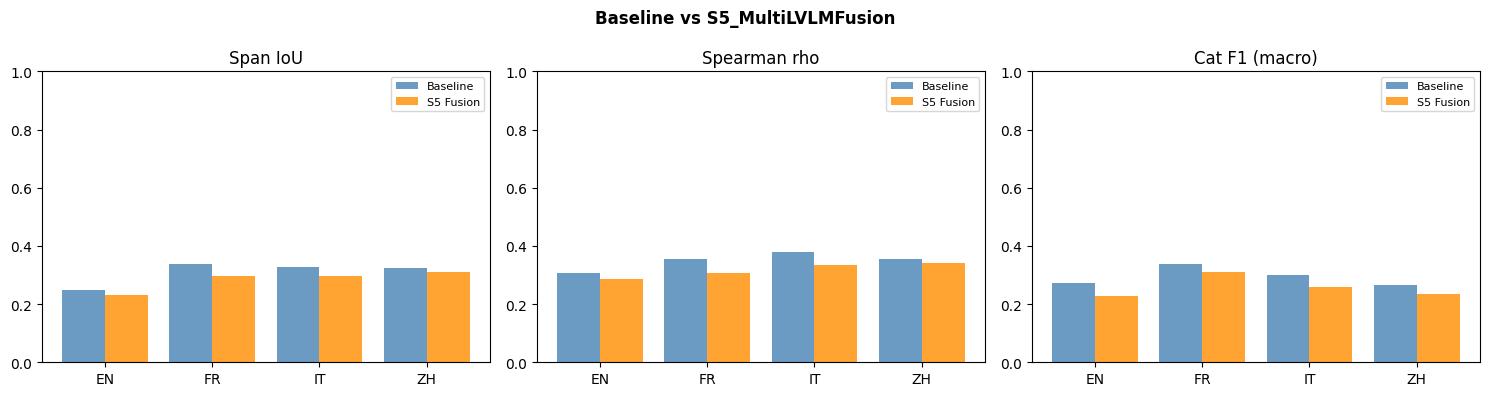

In [ ]:
FastVisionModel.for_inference(model)
device = next(model.parameters()).device

def run_inference(conv):
    msgs = conv['messages']
    text_input = processor.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
    image_inputs, video_inputs = process_vision_info(msgs)
    inputs = processor(text=[text_input], images=image_inputs, videos=video_inputs,
                       padding=True, return_tensors='pt').to(device)
    with torch.no_grad():
        out = model.generate(**inputs, max_new_tokens=MAX_NEW_TOKENS,
                             do_sample=False, pad_token_id=processor.tokenizer.pad_token_id)
    return processor.batch_decode(out[:, inputs['input_ids'].shape[1]:], skip_special_tokens=True)[0].strip()

LABEL_NORM = {'mischaracterisation':'mischaracterization','ocr_problem':'OCR','ocr problem':'OCR','ocr':'OCR','fabrication':'invention'}

def parse_model_output(raw):
    m = re.search(r'\[.*\]', raw, re.DOTALL)
    if not m: return []
    try: spans = json.loads(m.group())
    except: return []
    out = []
    for sp in spans:
        if not isinstance(sp, dict) or 'text' not in sp: continue
        text  = str(sp['text']).strip()
        if not text: continue
        label = LABEL_NORM.get(str(sp.get('label','other')).lower().strip(), str(sp.get('label','other')).lower().strip())
        if label not in VALID_LABELS: label = 'other'
        prob = max(0.0, min(1.0, float(sp.get('prob', 0.8))))
        out.append({'text': text, 'prob': prob, 'label': label})
    return out

def find_span_pos(response, text):
    if not text: return None
    pos = response.find(text)
    if pos != -1: return pos, pos + len(text)
    pos = response.lower().find(text.lower())
    if pos != -1: return pos, pos + len(text)
    if len(text) >= 8:
        tl, rl, tlen = text.lower(), response.lower(), len(text)
        step = max(1, tlen // 4)
        best_r, best_pos = 0.0, 0
        for i in range(0, max(1, len(response)-tlen+1), step):
            r = difflib.SequenceMatcher(None, rl[i:i+tlen], tl).ratio()
            if r > best_r: best_r, best_pos = r, i
        for i in range(max(0, best_pos-step), min(len(response)-tlen+1, best_pos+step+1)):
            r = difflib.SequenceMatcher(None, rl[i:i+tlen], tl).ratio()
            if r > best_r: best_r, best_pos = r, i
        if best_r >= 0.80: return best_pos, best_pos + tlen
    return None

def map_spans_to_positions(response, parsed):
    result, used = [], set()
    for sp in parsed:
        pos = find_span_pos(response, sp['text'])
        if pos is None: continue
        start, end = pos
        if len(set(range(start, end)) & used) > (end-start)*0.5: continue
        result.append({'start': start, 'end': end, 'prob': sp['prob'], 'label': sp['label']})
        used.update(range(start, end))
    return sorted(result, key=lambda x: x['start'])

def predict_one(conv):
    return map_spans_to_positions(conv['_response'], parse_model_output(run_inference(conv)))

def span_iou(pred, gold):
    p = set(i for s in pred for i in range(s['start'], s['end']))
    g = set(i for s in gold for i in range(s['start'], s['end']))
    if not p and not g: return 1.0
    return len(p & g) / len(p | g)

def spearman_rho(pred, gold, resp_len):
    pa = np.zeros(resp_len); ga = np.zeros(resp_len)
    for s in pred:
        for i in range(s['start'], min(s['end'], resp_len)): pa[i] = max(pa[i], s['prob'])
    for s in gold:
        for i in range(s['start'], min(s['end'], resp_len)): ga[i] = max(ga[i], s['prob'])
    if np.allclose(pa, pa[0]) and np.allclose(ga, ga[0]):
        return 1.0 if np.allclose(pa, ga) else 0.0
    rho, _ = spearmanr(pa, ga)
    return float(rho) if not np.isnan(rho) else 0.0

def category_f1(pred, gold, min_iou=0.3):
    tp, fp, fn = Counter(), Counter(), Counter()
    used_gold, used_pred = set(), set()
    for pi, p in enumerate(pred):
        pc = set(range(p['start'], p['end']))
        best_iou, best_gi = 0.0, -1
        for gi, g in enumerate(gold):
            if gi in used_gold: continue
            gc = set(range(g['start'], g['end']))
            iou = len(pc & gc) / max(len(pc | gc), 1)
            if iou > best_iou: best_iou, best_gi = iou, gi
        if best_iou >= min_iou and best_gi != -1:
            if p['label'] == gold[best_gi]['label']: tp[gold[best_gi]['label']] += 1
            else: fp[p['label']] += 1; fn[gold[best_gi]['label']] += 1
            used_gold.add(best_gi); used_pred.add(pi)
    for pi, p in enumerate(pred):
        if pi not in used_pred: fp[p['label']] += 1
    for gi, g in enumerate(gold):
        if gi not in used_gold: fn[g['label']] += 1
    scores = {}
    for cat in LABEL_ORDER:
        prec = tp[cat] / max(tp[cat]+fp[cat], 1)
        rec  = tp[cat] / max(tp[cat]+fn[cat], 1)
        scores[cat] = 2*prec*rec / max(prec+rec, 1e-9)
    scores['macro'] = float(np.mean(list(scores.values())))
    return scores

def evaluate_predictions(convs, predictions):
    ious, rhos, all_pred, all_gold = [], [], [], []
    for conv in convs:
        gold = conv['_labels']; pred = predictions.get(conv['_id'], [])
        ious.append(span_iou(pred, gold))
        rhos.append(spearman_rho(pred, gold, len(conv['_response'])))
        all_pred.extend(pred); all_gold.extend(gold)
    return {'mean_iou': float(np.mean(ious)), 'mean_spearman': float(np.nanmean(rhos)),
            'cat_f1': category_f1(all_pred, all_gold), 'n': len(convs)}

val_by_lang = defaultdict(list)
for conv in all_val_convs: val_by_lang[conv['_lang']].append(conv)
val_predictions = {}
for lang, convs in val_by_lang.items():
    convs = convs[:MAX_VAL_SAMPLES]
    print(f'Evaluating {lang.upper()} ({len(convs)} samples)...')
    for conv in tqdm(convs, desc=lang.upper()):
        try: val_predictions[conv['_id']] = predict_one(conv)
        except: val_predictions[conv['_id']] = []

results_by_lang = {}
print('=' * 60)
print(f'RESULTS — {STRATEGY} (mode={FUSION_MODE})')
print('=' * 60)
for lang, convs in val_by_lang.items():
    m = evaluate_predictions(convs[:MAX_VAL_SAMPLES], val_predictions)
    results_by_lang[lang] = m
    print(f'[{lang.upper()}]  IoU={m["mean_iou"]:.4f}  Spearman={m["mean_spearman"]:.4f}  CatF1={m["cat_f1"]["macro"]:.4f}')

all_val_limited = [c for lc in val_by_lang.values() for c in lc[:MAX_VAL_SAMPLES]]
overall = evaluate_predictions(all_val_limited, val_predictions)
print(f'[OVERALL]  IoU={overall["mean_iou"]:.4f}  Spearman={overall["mean_spearman"]:.4f}  CatF1={overall["cat_f1"]["macro"]:.4f}')

rows = []
for lang in LANGUAGES:
    if lang not in results_by_lang: continue
    m = results_by_lang[lang]
    row = {'Language': lang.upper(), 'Span IoU': round(m['mean_iou'],4),
           'Spearman rho': round(m['mean_spearman'],4), 'Cat F1 (macro)': round(m['cat_f1']['macro'],4)}
    for cat in LABEL_ORDER: row[f'F1({cat[:4]})'] = round(m['cat_f1'].get(cat,0.0),4)
    rows.append(row)
row_all = {'Language':'OVERALL','Span IoU':round(overall['mean_iou'],4),
           'Spearman rho':round(overall['mean_spearman'],4),'Cat F1 (macro)':round(overall['cat_f1']['macro'],4)}
for cat in LABEL_ORDER: row_all[f'F1({cat[:4]})'] = round(overall['cat_f1'].get(cat,0.0),4)
rows.append(row_all)
results_df = pd.DataFrame(rows)
results_df.to_csv(OUTPUT_DIR/f'{STRATEGY}_results.csv', index=False)

if BASELINE_CSV.exists():
    baseline_df = pd.read_csv(BASELINE_CSV)
    if 'Spearman \u03c1' in baseline_df.columns:
        baseline_df = baseline_df.rename(columns={'Spearman \u03c1': 'Spearman rho'})
    fig, axes = plt.subplots(1, 3, figsize=(15,4))
    langs_p = [l for l in LANGUAGES if l.upper() in results_df['Language'].values]
    for ax, met in zip(axes, ['Span IoU','Spearman rho','Cat F1 (macro)']):
        bv = [float(baseline_df[baseline_df['Language']==l.upper()][met].values[0]) for l in langs_p]
        av = [float(results_df[results_df['Language']==l.upper()][met].values[0]) for l in langs_p]
        x = np.arange(len(langs_p))
        ax.bar(x-0.2, bv, 0.4, label='Baseline', color='steelblue', alpha=0.8)
        ax.bar(x+0.2, av, 0.4, label='S5 Fusion', color='darkorange', alpha=0.8)
        ax.set_xticks(x); ax.set_xticklabels([l.upper() for l in langs_p])
        ax.set_title(met); ax.set_ylim(0,1); ax.legend(fontsize=8)
    plt.suptitle(f'Baseline vs {STRATEGY}', fontweight='bold')
    plt.tight_layout(); plt.savefig(OUTPUT_DIR/'comparison_chart.png', dpi=150); plt.show()
else:
    print(f'Baseline CSV not found at {BASELINE_CSV}')